# Comparativa de Modelos: Gemini-2.5-Flash vs Gemini-2.5-Pro

Este notebook compara el rendimiento de dos modelos en pruebas de evaluación y stress test:
- **Gemini-2.5-Flash**: Modelo rápido optimizado para latencia
- **Gemini-2.5-Pro**: Modelo premium optimizado para calidad

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 1. Carga de Datos

In [2]:
# Cargar resultados de evaluación
with open('evaluation_results_flash.json', 'r') as f:
    eval_flash = json.load(f)

with open('evaluation_results.json', 'r') as f:
    eval_pro = json.load(f)

# Cargar resultados de stress test
with open('stress_test_results_flash.json', 'r') as f:
    stress_flash = json.load(f)

with open('stress_test_results.json', 'r') as f:
    stress_pro = json.load(f)

print("Datos cargados exitosamente")
print(f"\nModelo Flash: {eval_flash['metadata']['model']}")
print(f"Modelo Pro: {eval_pro['metadata']['model']}")

Datos cargados exitosamente

Modelo Flash: models/gemini-2.5-flash
Modelo Pro: models/gemini-2.5-pro


## 2. Resumen General de Resultados

In [3]:
# Crear tabla resumen
summary_data = {
    'Métrica': ['Tests Evaluación', 'Éxito Evaluación (%)', 'Latencia Promedio Evaluación (s)', 
                'Tests Stress', 'Éxito Stress (%)', 'Latencia Promedio Stress (s)'],
    'Gemini-2.5-Flash': [
        eval_flash['summary']['total_tests'],
        round(eval_flash['summary']['success_rate'] * 100, 2),
        round(eval_flash['summary']['avg_execution_time'], 2),
        stress_flash['summary']['total_tests'],
        round(stress_flash['summary']['success_rate'] * 100, 2),
        round(stress_flash['summary']['avg_execution_time'], 2)
    ],
    'Gemini-2.5-Pro': [
        eval_pro['summary']['total_tests'],
        round(eval_pro['summary']['success_rate'] * 100, 2),
        round(eval_pro['summary']['avg_execution_time'], 2),
        stress_pro['summary']['total_tests'],
        round(stress_pro['summary']['success_rate'] * 100, 2),
        round(stress_pro['summary']['avg_execution_time'], 2)
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary

,Métrica,Gemini-2.5-Flash,Gemini-2.5-Pro
0,Tests Evaluación,13.00,13.00
1,Éxito Evaluación (%),84.62,92.31
2,Latencia Promedio Evaluación (s),3.60,17.44
3,Tests Stress,20.00,20.00
4,Éxito Stress (%),80.00,95.00
5,Latencia Promedio Stress (s),19.34,33.84


## 3. Comparativa General: Tasa de Éxito

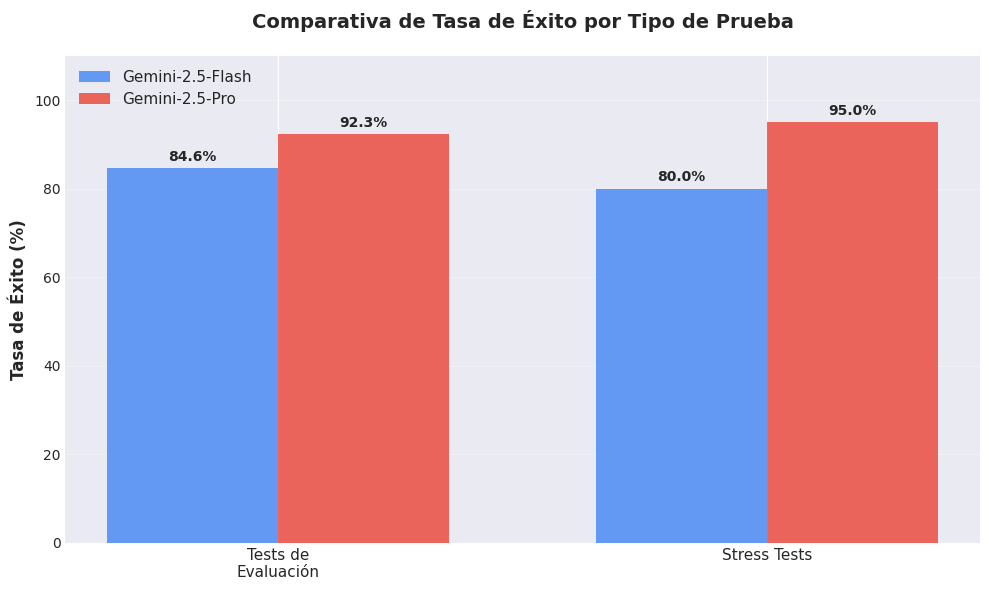

In [4]:
# Datos para el gráfico de tasa de éxito
test_types = ['Tests de\nEvaluación', 'Stress Tests']
flash_success = [
    eval_flash['summary']['success_rate'] * 100,
    stress_flash['summary']['success_rate'] * 100
]
pro_success = [
    eval_pro['summary']['success_rate'] * 100,
    stress_pro['summary']['success_rate'] * 100
]

x = np.arange(len(test_types))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, flash_success, width, label='Gemini-2.5-Flash', color='#4285F4', alpha=0.8)
bars2 = ax.bar(x + width/2, pro_success, width, label='Gemini-2.5-Pro', color='#EA4335', alpha=0.8)

ax.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de Tasa de Éxito por Tipo de Prueba', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(test_types, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=10, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

## 4. Comparativa General: Latencia Promedio

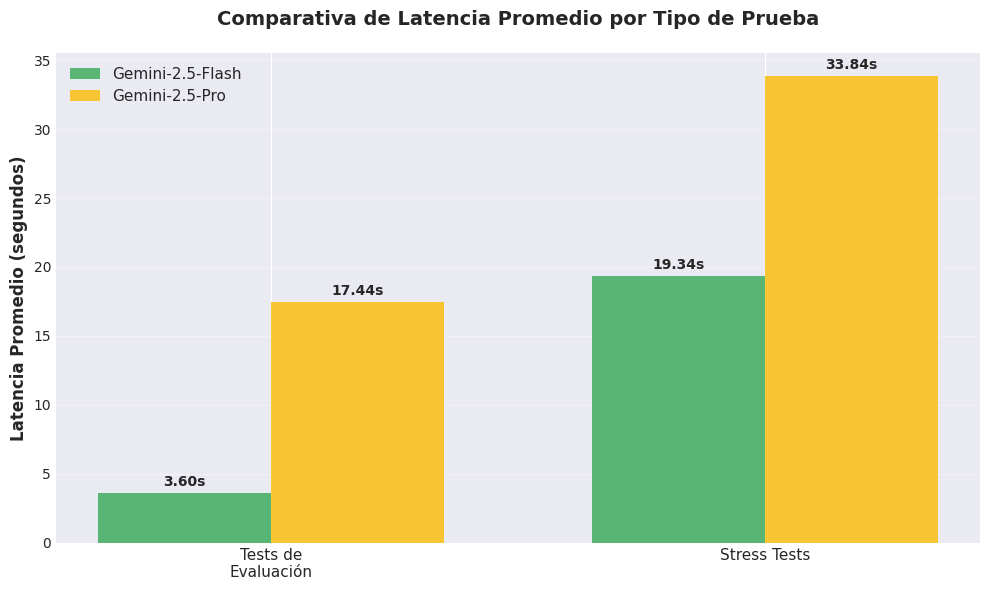

In [5]:
# Datos para el gráfico de latencia
flash_latency = [
    eval_flash['summary']['avg_execution_time'],
    stress_flash['summary']['avg_execution_time']
]
pro_latency = [
    eval_pro['summary']['avg_execution_time'],
    stress_pro['summary']['avg_execution_time']
]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, flash_latency, width, label='Gemini-2.5-Flash', color='#34A853', alpha=0.8)
bars2 = ax.bar(x + width/2, pro_latency, width, label='Gemini-2.5-Pro', color='#FBBC04', alpha=0.8)

ax.set_ylabel('Latencia Promedio (segundos)', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de Latencia Promedio por Tipo de Prueba', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(test_types, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
def autolabel_latency(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}s',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=10, fontweight='bold')

autolabel_latency(bars1)
autolabel_latency(bars2)

plt.tight_layout()
plt.show()

## 5. Tests de Evaluación: Éxito por Categoría

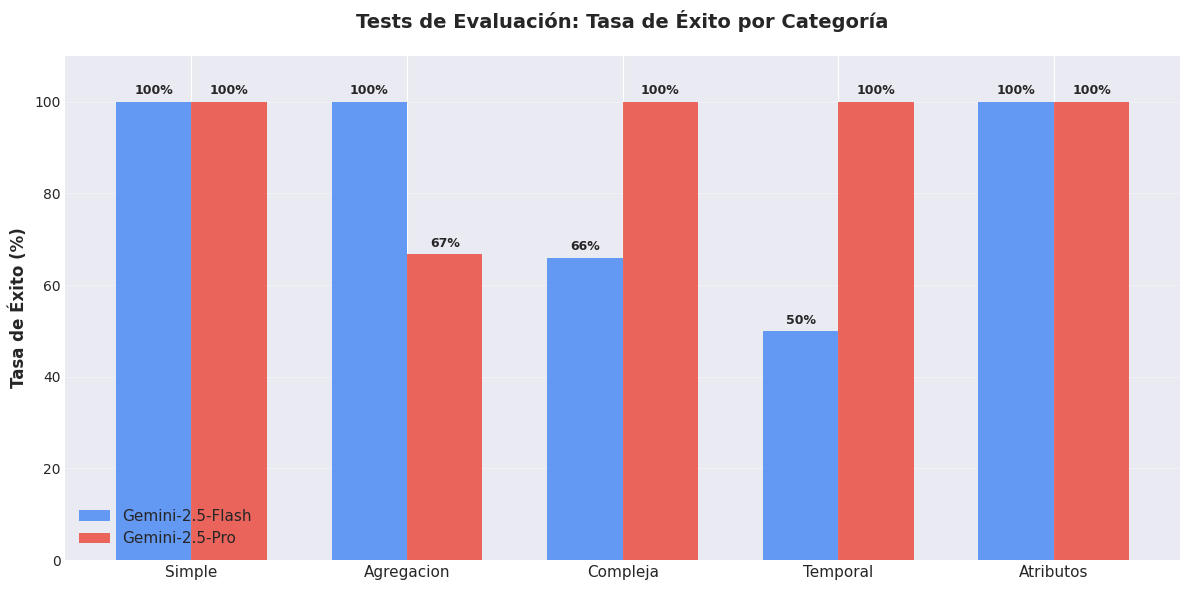

In [6]:
# Extraer datos por categoría
categories_eval = list(eval_flash['by_category'].keys())
flash_success_cat = [eval_flash['by_category'][cat]['success_rate'] * 100 for cat in categories_eval]
pro_success_cat = [eval_pro['by_category'][cat]['success_rate'] * 100 for cat in categories_eval]

x_cat = np.arange(len(categories_eval))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_cat - width/2, flash_success_cat, width, label='Gemini-2.5-Flash', color='#4285F4', alpha=0.8)
bars2 = ax.bar(x_cat + width/2, pro_success_cat, width, label='Gemini-2.5-Pro', color='#EA4335', alpha=0.8)

ax.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax.set_title('Tests de Evaluación: Tasa de Éxito por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_cat)
ax.set_xticklabels([cat.capitalize() for cat in categories_eval], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
def autolabel_cat(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=9, fontweight='bold')

autolabel_cat(bars1)
autolabel_cat(bars2)

plt.tight_layout()
plt.show()

## 6. Tests de Evaluación: Latencia por Categoría

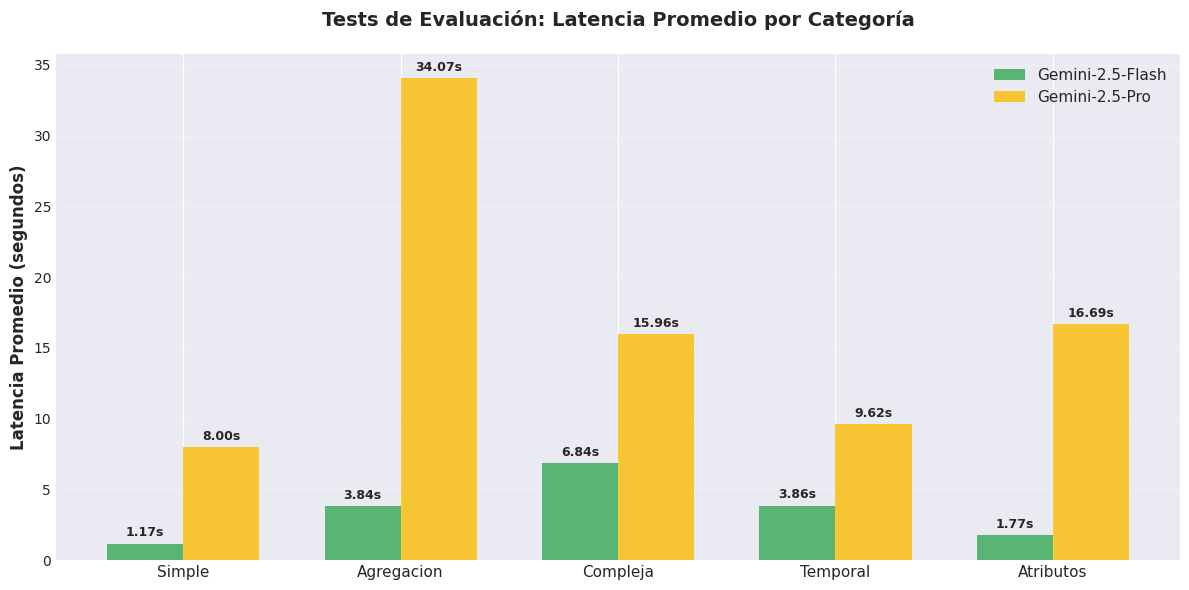

In [7]:
# Extraer latencias por categoría
flash_latency_cat = [eval_flash['by_category'][cat]['avg_time'] for cat in categories_eval]
pro_latency_cat = [eval_pro['by_category'][cat]['avg_time'] for cat in categories_eval]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_cat - width/2, flash_latency_cat, width, label='Gemini-2.5-Flash', color='#34A853', alpha=0.8)
bars2 = ax.bar(x_cat + width/2, pro_latency_cat, width, label='Gemini-2.5-Pro', color='#FBBC04', alpha=0.8)

ax.set_ylabel('Latencia Promedio (segundos)', fontsize=12, fontweight='bold')
ax.set_title('Tests de Evaluación: Latencia Promedio por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_cat)
ax.set_xticklabels([cat.capitalize() for cat in categories_eval], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
def autolabel_lat(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}s',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=9, fontweight='bold')

autolabel_lat(bars1)
autolabel_lat(bars2)

plt.tight_layout()
plt.show()

## 7. Stress Tests: Éxito por Dificultad

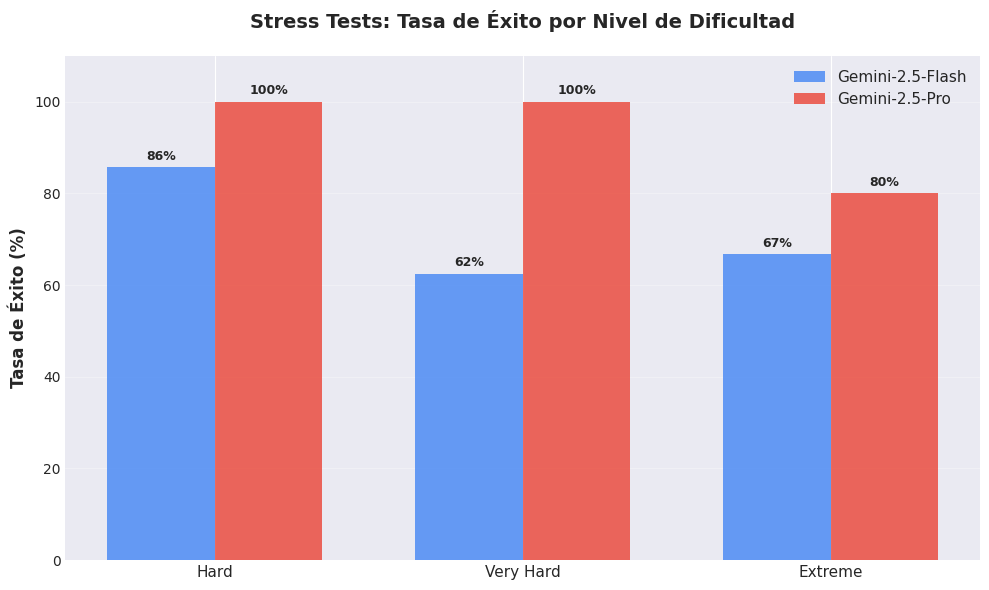

In [8]:
# Extraer datos por dificultad
difficulties = list(stress_flash['by_difficulty'].keys())
flash_success_diff = [stress_flash['by_difficulty'][diff]['success_rate'] * 100 for diff in difficulties]
pro_success_diff = [stress_pro['by_difficulty'][diff]['success_rate'] * 100 for diff in difficulties]

x_diff = np.arange(len(difficulties))

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_diff - width/2, flash_success_diff, width, label='Gemini-2.5-Flash', color='#4285F4', alpha=0.8)
bars2 = ax.bar(x_diff + width/2, pro_success_diff, width, label='Gemini-2.5-Pro', color='#EA4335', alpha=0.8)

ax.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax.set_title('Stress Tests: Tasa de Éxito por Nivel de Dificultad', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_diff)
ax.set_xticklabels([diff.replace('_', ' ').title() for diff in difficulties], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

autolabel_cat(bars1)
autolabel_cat(bars2)

plt.tight_layout()
plt.show()

## 8. Stress Tests: Latencia por Dificultad

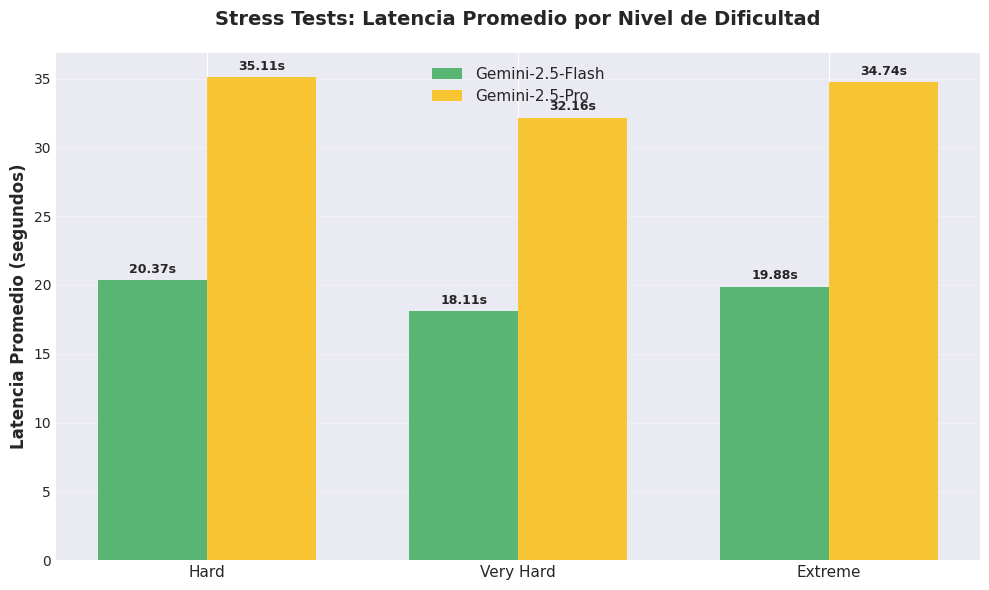

In [9]:
# Extraer latencias por dificultad
flash_latency_diff = [stress_flash['by_difficulty'][diff]['avg_time'] for diff in difficulties]
pro_latency_diff = [stress_pro['by_difficulty'][diff]['avg_time'] for diff in difficulties]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_diff - width/2, flash_latency_diff, width, label='Gemini-2.5-Flash', color='#34A853', alpha=0.8)
bars2 = ax.bar(x_diff + width/2, pro_latency_diff, width, label='Gemini-2.5-Pro', color='#FBBC04', alpha=0.8)

ax.set_ylabel('Latencia Promedio (segundos)', fontsize=12, fontweight='bold')
ax.set_title('Stress Tests: Latencia Promedio por Nivel de Dificultad', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_diff)
ax.set_xticklabels([diff.replace('_', ' ').title() for diff in difficulties], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

autolabel_lat(bars1)
autolabel_lat(bars2)

plt.tight_layout()
plt.show()

## 9. Stress Tests: Éxito por Categoría

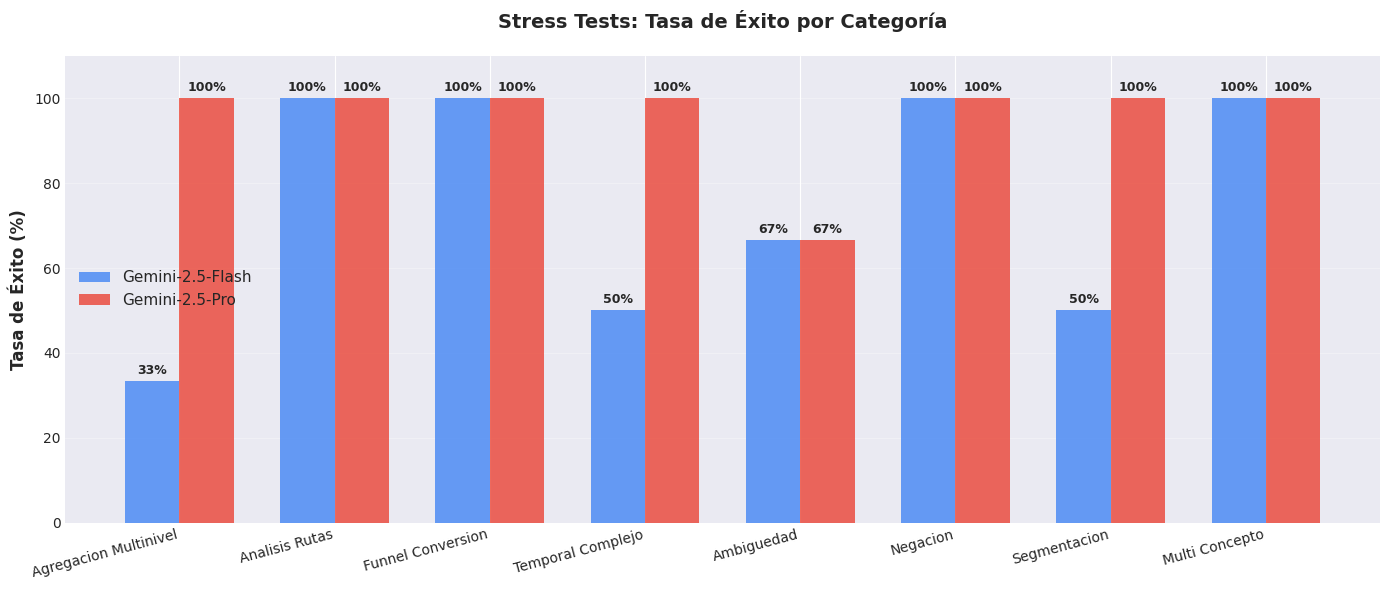

In [10]:
# Extraer datos por categoría de stress test
categories_stress = list(stress_flash['by_category'].keys())
flash_success_stress_cat = [stress_flash['by_category'][cat]['success_rate'] * 100 for cat in categories_stress]
pro_success_stress_cat = [stress_pro['by_category'][cat]['success_rate'] * 100 for cat in categories_stress]

x_stress_cat = np.arange(len(categories_stress))

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x_stress_cat - width/2, flash_success_stress_cat, width, label='Gemini-2.5-Flash', color='#4285F4', alpha=0.8)
bars2 = ax.bar(x_stress_cat + width/2, pro_success_stress_cat, width, label='Gemini-2.5-Pro', color='#EA4335', alpha=0.8)

ax.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax.set_title('Stress Tests: Tasa de Éxito por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_stress_cat)
ax.set_xticklabels([cat.replace('_', ' ').title() for cat in categories_stress], fontsize=10, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

autolabel_cat(bars1)
autolabel_cat(bars2)

plt.tight_layout()
plt.show()

## 10. Stress Tests: Latencia por Categoría

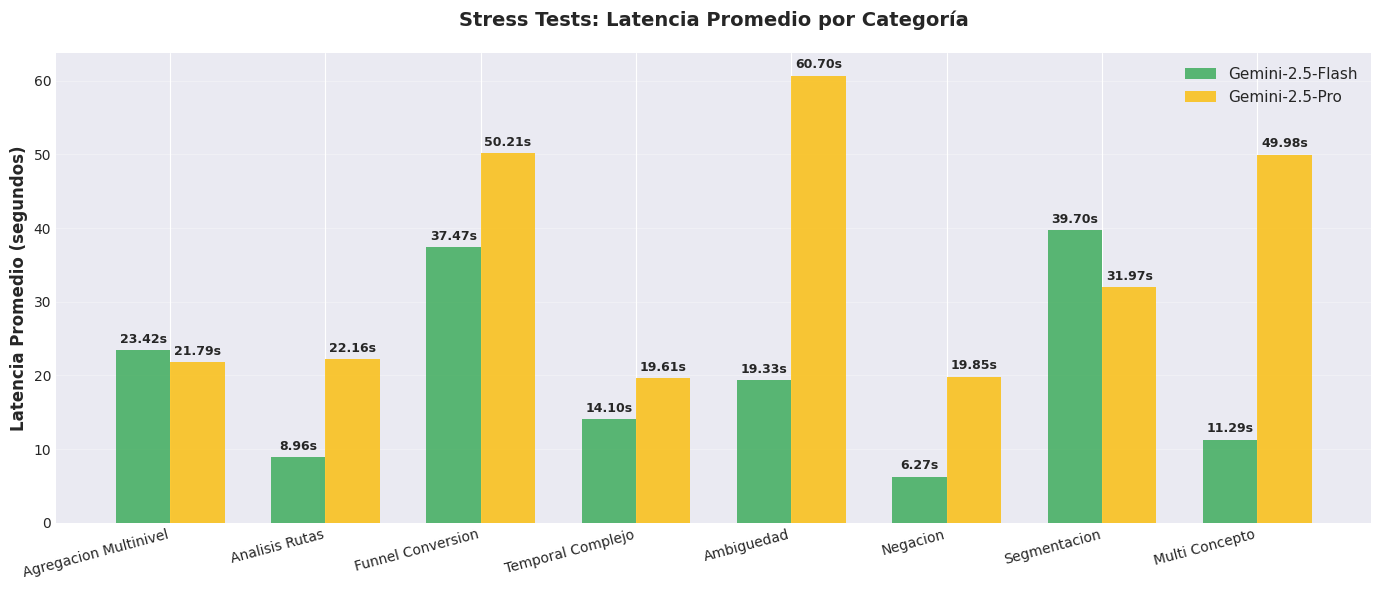

In [11]:
# Extraer latencias por categoría de stress test
flash_latency_stress_cat = [stress_flash['by_category'][cat]['avg_time'] for cat in categories_stress]
pro_latency_stress_cat = [stress_pro['by_category'][cat]['avg_time'] for cat in categories_stress]

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x_stress_cat - width/2, flash_latency_stress_cat, width, label='Gemini-2.5-Flash', color='#34A853', alpha=0.8)
bars2 = ax.bar(x_stress_cat + width/2, pro_latency_stress_cat, width, label='Gemini-2.5-Pro', color='#FBBC04', alpha=0.8)

ax.set_ylabel('Latencia Promedio (segundos)', fontsize=12, fontweight='bold')
ax.set_title('Stress Tests: Latencia Promedio por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_stress_cat)
ax.set_xticklabels([cat.replace('_', ' ').title() for cat in categories_stress], fontsize=10, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

autolabel_lat(bars1)
autolabel_lat(bars2)

plt.tight_layout()
plt.show()

## 11. Análisis de Trade-offs: Éxito vs Latencia

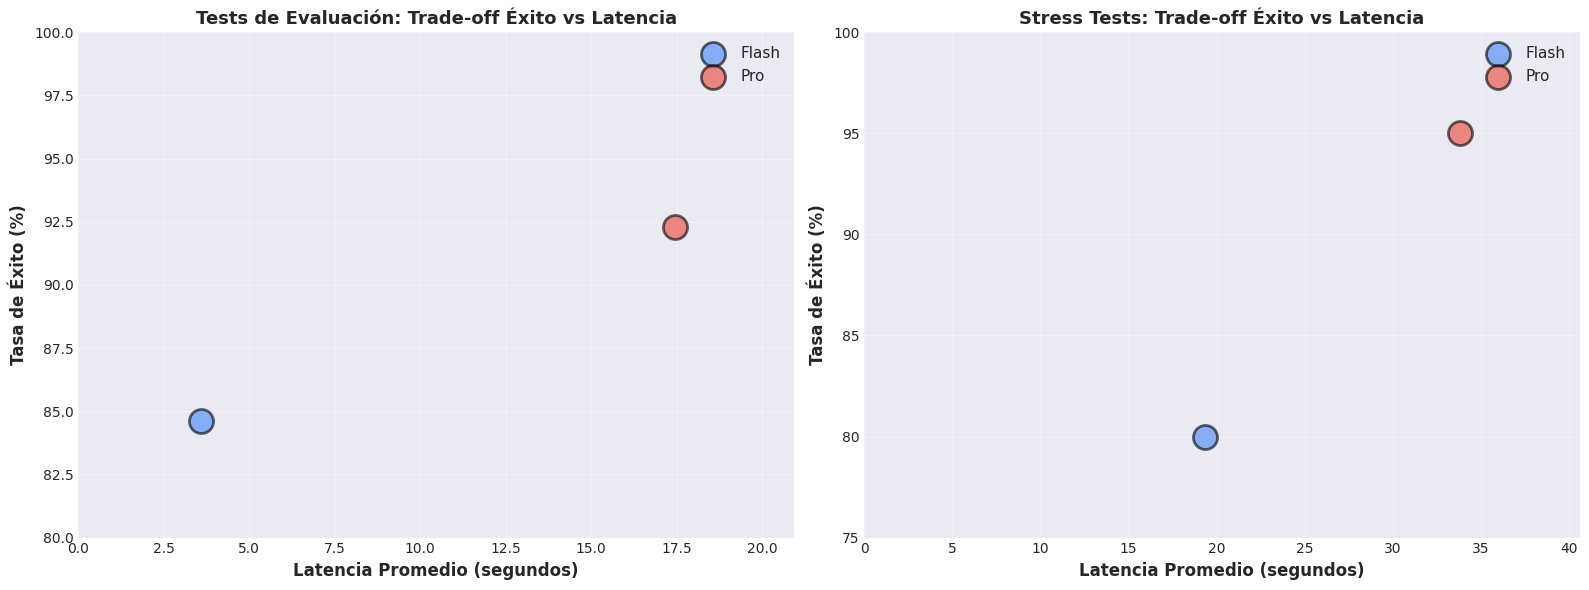

In [12]:
# Crear gráfico de dispersión para visualizar trade-offs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Tests de Evaluación
ax1.scatter([eval_flash['summary']['avg_execution_time']], 
           [eval_flash['summary']['success_rate'] * 100],
           s=300, c='#4285F4', alpha=0.6, label='Flash', edgecolors='black', linewidths=2)
ax1.scatter([eval_pro['summary']['avg_execution_time']], 
           [eval_pro['summary']['success_rate'] * 100],
           s=300, c='#EA4335', alpha=0.6, label='Pro', edgecolors='black', linewidths=2)

ax1.set_xlabel('Latencia Promedio (segundos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax1.set_title('Tests de Evaluación: Trade-off Éxito vs Latencia', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(eval_flash['summary']['avg_execution_time'], eval_pro['summary']['avg_execution_time']) * 1.2)
ax1.set_ylim(80, 100)

# Stress Tests
ax2.scatter([stress_flash['summary']['avg_execution_time']], 
           [stress_flash['summary']['success_rate'] * 100],
           s=300, c='#4285F4', alpha=0.6, label='Flash', edgecolors='black', linewidths=2)
ax2.scatter([stress_pro['summary']['avg_execution_time']], 
           [stress_pro['summary']['success_rate'] * 100],
           s=300, c='#EA4335', alpha=0.6, label='Pro', edgecolors='black', linewidths=2)

ax2.set_xlabel('Latencia Promedio (segundos)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax2.set_title('Stress Tests: Trade-off Éxito vs Latencia', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(stress_flash['summary']['avg_execution_time'], stress_pro['summary']['avg_execution_time']) * 1.2)
ax2.set_ylim(75, 100)

plt.tight_layout()
plt.show()

## 12. Conclusiones y Recomendaciones

In [13]:
# Calcular métricas comparativas
eval_success_diff = eval_pro['summary']['success_rate'] - eval_flash['summary']['success_rate']
eval_latency_diff = eval_flash['summary']['avg_execution_time'] - eval_pro['summary']['avg_execution_time']
stress_success_diff = stress_pro['summary']['success_rate'] - stress_flash['summary']['success_rate']
stress_latency_diff = stress_flash['summary']['avg_execution_time'] - stress_pro['summary']['avg_execution_time']

print("="*70)
print("RESUMEN DE COMPARATIVA ENTRE MODELOS")
print("="*70)
print("\n📊 TESTS DE EVALUACIÓN:")
print(f"  • Gemini-2.5-Pro tiene {eval_success_diff*100:.1f}% más de éxito que Flash")
print(f"  • Gemini-2.5-Flash es {abs(eval_latency_diff):.2f}s más rápido que Pro")
print(f"  • Flash es {(eval_latency_diff/eval_pro['summary']['avg_execution_time'])*100:.1f}% más rápido")

print("\n🔥 STRESS TESTS:")
print(f"  • Gemini-2.5-Pro tiene {stress_success_diff*100:.1f}% más de éxito que Flash")
print(f"  • Gemini-2.5-Flash es {abs(stress_latency_diff):.2f}s más rápido que Pro")
print(f"  • Flash es {(stress_latency_diff/stress_pro['summary']['avg_execution_time'])*100:.1f}% más rápido")

print("\n💡 RECOMENDACIONES:")
print("  ✓ Usar Gemini-2.5-Pro cuando:")
print("    - Se requiere máxima precisión y tasa de éxito")
print("    - Las queries son complejas (agregación multinivel, rutas)")
print("    - La latencia no es crítica (casos offline/batch)")
print("\n  ✓ Usar Gemini-2.5-Flash cuando:")
print("    - Se requiere baja latencia (APIs en tiempo real)")
print("    - Las queries son simples o de agregación básica")
print("    - El volumen de requests es alto y el costo importa")
print("="*70)

RESUMEN DE COMPARATIVA ENTRE MODELOS

📊 TESTS DE EVALUACIÓN:
  • Gemini-2.5-Pro tiene 7.7% más de éxito que Flash
  • Gemini-2.5-Flash es 13.84s más rápido que Pro
  • Flash es -79.4% más rápido

🔥 STRESS TESTS:
  • Gemini-2.5-Pro tiene 15.0% más de éxito que Flash
  • Gemini-2.5-Flash es 14.50s más rápido que Pro
  • Flash es -42.8% más rápido

💡 RECOMENDACIONES:
  ✓ Usar Gemini-2.5-Pro cuando:
    - Se requiere máxima precisión y tasa de éxito
    - Las queries son complejas (agregación multinivel, rutas)
    - La latencia no es crítica (casos offline/batch)

  ✓ Usar Gemini-2.5-Flash cuando:
    - Se requiere baja latencia (APIs en tiempo real)
    - Las queries son simples o de agregación básica
    - El volumen de requests es alto y el costo importa
